In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sim_wrapper.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

The first conversion (C1) pulse of the embedded amplifier is somewhat difficult to optimize, even in a simple linear simulation. We want to maximize the separation between the $|g\rangle$ and $|e\rangle$ trajectories after the C1 pulse, to maximize the output fidelity, but we also want the readout resonator to be emptied of photons after C1 to allow for rapid repeated measurements. 

The dispersive shift $\chi$ instrinsic to the readout causes the C1 process to be detuned for one or both trajectories, which leaves residual photon population in readout mode. But larger $\chi$ also enables more separation. The most relevant parameter space involves C1 amplitude and duration, readout pulse duration, amplifier mode $\kappa_b$, $\chi$, and readout $\kappa_a$. Other parameters will have smaller effects too. This is too large to fully explore, but we can contrain this space in a few ways.

First we set up the simulation.

In [20]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', 6.0e9*2*pi, is_excitation=True)
sim.add_param('wb', 4.0e9*2*pi)
sim.add_param('wc', 7.5e9*2*pi)
sim.add_paramsweep('logchi', 5, 7, 40) # in MHz
sim.add_paramsweep('logka', 4, 7, 30) # in MHz
sim.add_param('kb', 0.0e6 * 2 * np.pi)
sim.add_param('kc', 4e6 * 2 * np.pi)
sim.add_param('gab', 10e6 * 2 * np.pi)
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('gr', 10e6 * 2 * np.pi)
sim.add_paramsweep('qbstate', -1, 1, 2)

sim.add_param('amplR',  0.8)  # 0 - readout drive
sim.add_paramsweep('amplC1', 0.1, 0.4, 51)  # 6 - c1
sim.add_param('amplG', 0.0)  # 18 - gain
sim.add_param('amplC2', 0.0)  # 12 - c2
sim.add_param('wR', 6.0e9 * 2 * np.pi)  # 1
sim.add_param('wC1', -2.0e9 * 2 * np.pi)  # 7
sim.add_param('wG', 8.0e9 * 2 * np.pi)  # 19
sim.add_param('wC2', 3.5e9 * 2 * np.pi)  # 13
sim.add_param('rampR', 1e-9)  # 2
sim.add_param('rampC1', 1e-9)  # 8
sim.add_param('rampG', 1e-9)  # 14
sim.add_param('rampC2', 1e-9)  # 20
sim.add_param('startR', 15e-9)  # 3
sim.add_param('stopR', 35e-9)  # 4
sim.add_param('startC1', 45e-9)  # 9
sim.add_param('stopC1', 100e-9)  # 10
sim.add_param('startG', 110e-9)  # 21
sim.add_param('stopG', 170e-9)  # 22
sim.add_param('startC2', 190e-9)  # 15
sim.add_param('stopC2', 195e-9)  # 16
sim.add_param('phaseR', -np.pi / 4)  # 5
sim.add_param('phaseC1', np.pi / 3)  # 11
sim.add_param('phaseG', np.pi * 0.88)  # 23
sim.add_param('phaseC2', 0.0)  # 17

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')
C1pulse = sim.make_pulse('wC1', 'amplC1', 'phaseC1', 'startC1', 'stopC1', 'rampC1')

sim.add_EOM('s0', C1pulse)
sim.add_EOM('s1', Rpulse)

sim.add_EOM('a', '-1j*(wa+(10**logchi)*2*pi*qbstate)*a - 1j*gab*b*conjugate(s0) - 1j*s1*gr - 10**(logka)*a*2*pi')
sim.add_EOM('b', '-1j*wb*b - 1j*gab*a*s0 - kb*b')
sim.set_solve_type('decimate')

sim.specify_time(20, 600, d_factor=1)

sim.validate()

Simulation validation success!


We can play around with parameters for the quick sweep here, to give us a feeling for the optimization problem.

Default values gives us a reasonable readout scheme.

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


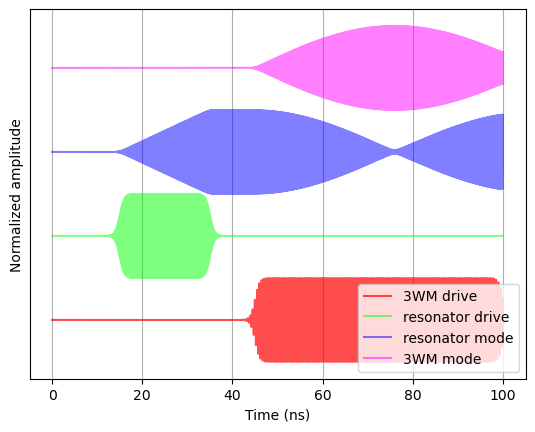

In [21]:
sim.param_dict_nosweep['logchi'] = 6
sim.param_dict_nosweep['logka'] = 5
sim.param_dict_nosweep['amplC1'] = 0.4

x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='3WM drive')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='resonator drive')
plt.plot(t*1e9, x[4,:]/np.max(x[4,:])+4,color=(0,0,1,0.5),label='resonator mode')
plt.plot(t*1e9, x[6,:]/np.max(x[6,:])+6,color=(1,0,1,0.5),label='3WM mode')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.yticks([])
plt.grid()

We can constrain the problem in the following way. Let's say that we want fast readout - we can fix the readout pulse duration.

As long as the pulse is still much longer than $1/\chi$ (i.e., $\chi$ is not unreasonably large), then for any $\kappa_a$ the separation will monotonically increase with time.

Then we can turn on the C1 pulse for variable amplitude and find which amplitude accomplishes a $\pi$ pulse, by ramping from zero amplitude and taking the amplitude when the C1 pulse stops decreasing final population of the $a$ mode. We want to fix the amplitude to C1 duration, since amplitude has no nonlinear effect, but duration can affect spectrum of C1.

For now, we set duration to be constant - this gives us a particular C1 pulse amplitude and duration. We sweep $\kappa_a$ and $\chi$, and plot the final state separation, and final $a$ population for $|g\rangle$ and $|e\rangle$. 

In [22]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 12000/12000 [00:38<00:00, 315.60it/s]


 
...finished GPU solve!


This step below is kind of hacky - I need to better implement different decimation frequencies (although the demodulation will always be one frequency - you can just rerun sim if you need more)

In [23]:
Id = I[:,:,:,:,:,0::3]
Qd = Q[:,:,:,:,:,0::3]
td = t[:,:,:,:,0::3]

C:\Users\boris\AppData\Local\Temp\ipykernel_32652\3459413706.py:16: RuntimeWarning: divide by zero encountered in log10
  plt.pcolor(np.log10(a_nbar[logchi_i,logka_i,qb_state,:, :]), vmin=-3, vmax=2)
C:\Users\boris\AppData\Local\Temp\ipykernel_32652\3459413706.py:20: RuntimeWarning: divide by zero encountered in log10
  plt.pcolor(np.log10(b_nbar[logchi_i,logka_i,qb_state,:, :]), vmin=-3, vmax=2)


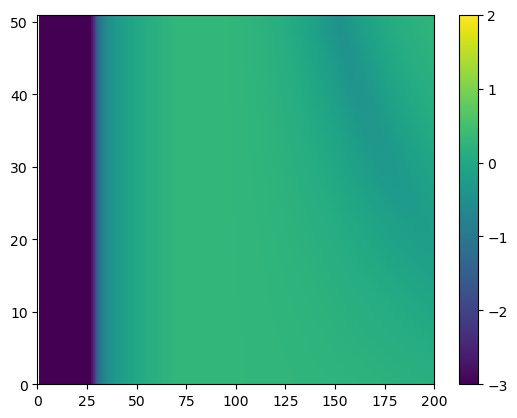

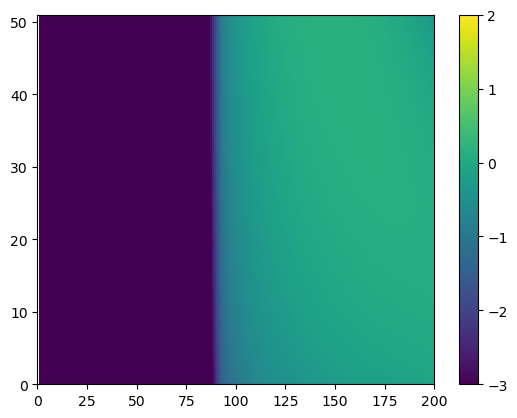

In [24]:
a_nbar = np.sqrt(Id[4,:]**2+Qd[4,:]**2)
b_nbar = np.sqrt(Id[6,:]**2+Qd[6,:]**2)

a_separation = np.sqrt((Id[4,:,:,1,:,:]-Id[4,:,:,0,:,:])**2 + (Qd[4,:,:,1,:,:]-Qd[4,:,:,0,:,:])**2)
b_separation = np.sqrt((Id[6,:,:,1,:,:]-Id[6,:,:,0,:,:])**2 + (Qd[6,:,:,1,:,:]-Qd[6,:,:,0,:,:])**2)

logchi = sim.paramsweep_dict['logchi']
logka = sim.paramsweep_dict['logka']
amplC1 = sim.paramsweep_dict['amplC1']

logchi_i = 28
logka_i = 10
qb_state = 0

plt.figure(4)
plt.pcolor(np.log10(a_nbar[logchi_i,logka_i,qb_state,:, :]), vmin=-3, vmax=2)
plt.colorbar()

plt.figure(5)
plt.pcolor(np.log10(b_nbar[logchi_i,logka_i,qb_state,:, :]), vmin=-3, vmax=2)
plt.colorbar()

# plt.figure(4)
# plt.plot(np.log10(a_nbar[10,10,0,:, -1]+a_nbar[10,10,1,:, -1]))


In [25]:
'''
I know this looks silly but trying to pick out the amplC1 to make a pi pulse it with np.diff() and np.where() was just 
very opaque
'''

a_residual_nbar = np.zeros([len(logchi),len(logka),2])
b_final_separation = np.zeros([len(logchi),len(logka)])
best_amplC1 = np.zeros([len(logchi),len(logka),2])

for i in range(0,len(logchi)):
    for j in range(0,len(logka)):
        for k in range(0,2): # qb state
            for l in range(1,len(amplC1)):
                if a_nbar[i,j,k,l,-1]>a_nbar[i,j,k,l-1,-1]:
                    break
            a_residual_nbar[i,j,k] = a_nbar[i,j,k,l,-1]
            best_amplC1[i,j,k] = amplC1[l]
            if k == 0:
                b_final_separation[i,j] = b_separation[i,j,l-1,-1]
                

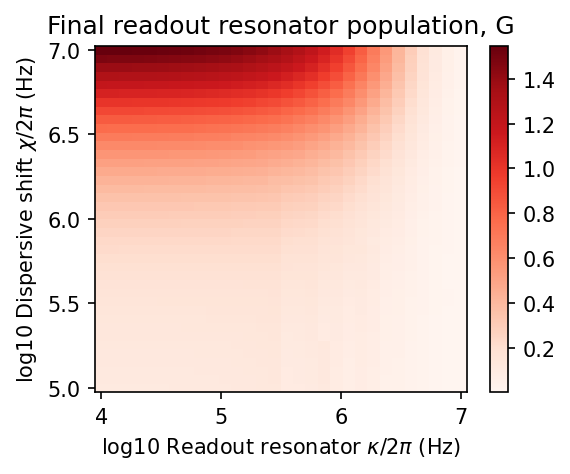

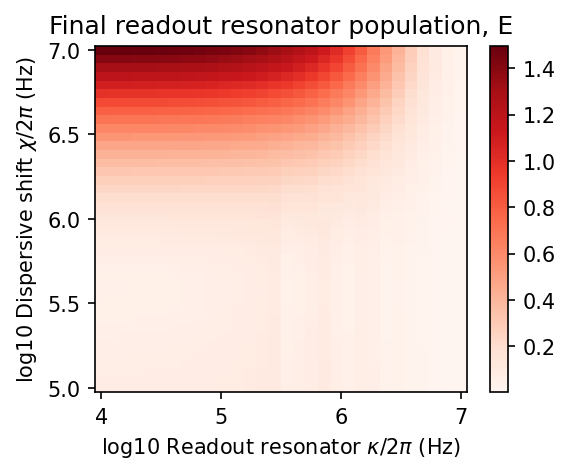

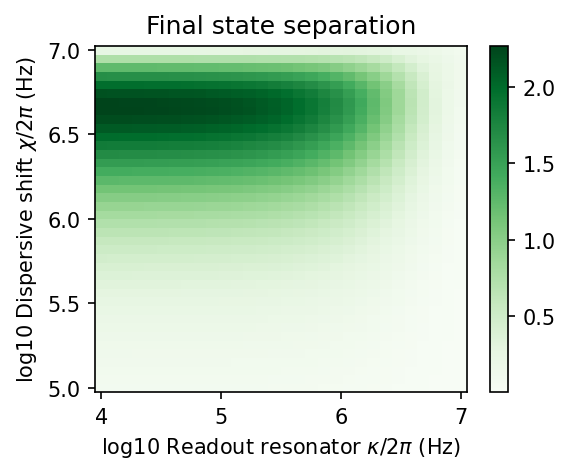

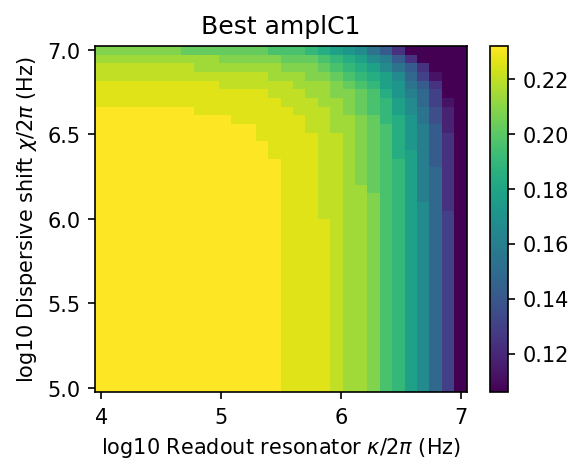

In [26]:
plt.figure(figsize=(4,3),dpi=150)
plt.pcolor(logka, logchi, a_residual_nbar[:,:,0],cmap='Reds')
plt.xlabel('log10 Readout resonator $\kappa / 2 \pi$ (Hz)')
plt.ylabel('log10 Dispersive shift $\chi / 2 \pi$ (Hz)')
plt.title('Final readout resonator population, G')
plt.colorbar()

plt.figure(figsize=(4,3),dpi=150)
plt.pcolor(logka, logchi, a_residual_nbar[:,:,1],cmap='Reds')
plt.xlabel('log10 Readout resonator $\kappa / 2 \pi$ (Hz)')
plt.ylabel('log10 Dispersive shift $\chi / 2 \pi$ (Hz)')
plt.title('Final readout resonator population, E')
plt.colorbar()

plt.figure(figsize=(4,3),dpi=150)
plt.pcolor(logka, logchi, b_final_separation,cmap='Greens')
plt.xlabel('log10 Readout resonator $\kappa / 2 \pi$ (Hz)')
plt.ylabel('log10 Dispersive shift $\chi / 2 \pi$ (Hz)')
plt.title('Final state separation')
plt.colorbar()

plt.figure(figsize=(4,3),dpi=150)
plt.pcolor(logka, logchi, best_amplC1[:,:,1])
plt.xlabel('log10 Readout resonator $\kappa / 2 \pi$ (Hz)')
plt.ylabel('log10 Dispersive shift $\chi / 2 \pi$ (Hz)')
plt.title('Best amplC1')
plt.colorbar()

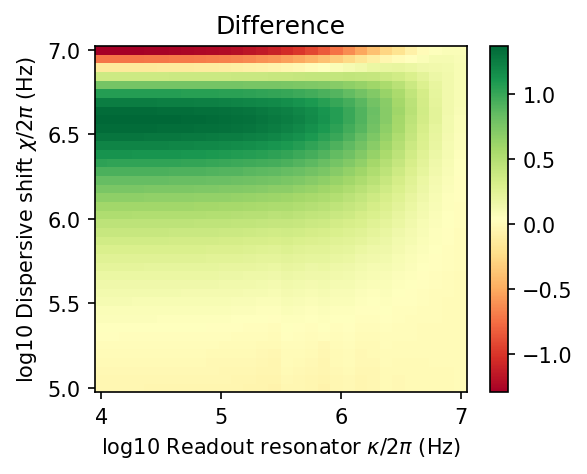

In [27]:
plt.figure(figsize=(4,3),dpi=150)
plt.pcolor(logka, logchi, b_final_separation-a_residual_nbar[:,:,0],cmap='RdYlGn')
plt.title('Difference')
plt.xlabel('log10 Readout resonator $\kappa / 2 \pi$ (Hz)')
plt.ylabel('log10 Dispersive shift $\chi / 2 \pi$ (Hz)')
plt.colorbar()

Next steps: do resonator linewidth study:
 - from port
 - hybridization with SNAIL
 - SWAP pulse duration
 
Here the C1 is 20 ns, so spectral width on order of 50 MHz

In [2]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', 6.0e9*2*pi, is_excitation=True)
sim.add_param('wb', 4.0e9*2*pi)
sim.add_param('wc', 7.5e9*2*pi)


sim.add_paramsweep('logchi', 4, 7.5, 21) # in MHz
sim.add_paramsweep('stopC1', 50e-9, 100e-9, 26)  # 10

sim.add_param('logka', 4) # in MHz


sim.add_param('kb', 0.2e6 * 2 * np.pi)
sim.add_param('kc', 4e6 * 2 * np.pi)
sim.add_param('gab', 10e6 * 2 * np.pi)
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('gr', 10e6 * 2 * np.pi)
sim.add_paramsweep('qbstate', -1, 1, 2)

sim.add_param('amplR',  0.8)  # 0 - readout drive
sim.add_paramsweep('amplC1', 0, 2, 101)  # 6 - c1
sim.add_param('amplG', 0.0)  # 18 - gain
sim.add_param('amplC2', 0.0)  # 12 - c2
sim.add_param('wR', 6.0e9 * 2 * np.pi)  # 1
sim.add_param('wC1', -2.0e9 * 2 * np.pi)  # 7
sim.add_param('wG', 8.0e9 * 2 * np.pi)  # 19
sim.add_param('wC2', 3.5e9 * 2 * np.pi)  # 13
sim.add_param('rampR', 1e-9)  # 2
sim.add_param('rampC1', 1e-9)  # 8
sim.add_param('rampG', 1e-9)  # 14
sim.add_param('rampC2', 1e-9)  # 20
sim.add_param('startR', 15e-9)  # 3
sim.add_param('stopR', 35e-9)  # 4
sim.add_param('startC1', 45e-9)  # 9

sim.add_param('startG', 110e-9)  # 21
sim.add_param('stopG', 170e-9)  # 22
sim.add_param('startC2', 190e-9)  # 15
sim.add_param('stopC2', 195e-9)  # 16
sim.add_param('phaseR', -np.pi / 4)  # 5
sim.add_param('phaseC1', np.pi / 3)  # 11
sim.add_param('phaseG', np.pi * 0.88)  # 23
sim.add_param('phaseC2', 0.0)  # 17

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')
C1pulse = sim.make_pulse('wC1', 'amplC1', 'phaseC1', 'startC1', 'stopC1', 'rampC1')

sim.add_EOM('s0', C1pulse)
sim.add_EOM('s1', Rpulse)

sim.add_EOM('a', '-1j*(wa+(10**logchi)*2*pi*qbstate)*a - 1j*gab*b*conjugate(s0) - 1j*s1*gr - 10**(logka)*a*2*pi')
sim.add_EOM('b', '-1j*wb*b - 1j*gab*a*s0 - kb*b')
sim.set_solve_type('decimate')

sim.specify_time(20, 600, d_factor=1)

sim.validate()

Simulation validation success!


In [3]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 12000/12000 [00:32<00:00, 365.26it/s]


 
...finished GPU solve!


In [4]:
Id = I[:,:,:,:,:,0::3]
Qd = Q[:,:,:,:,:,0::3]
td = t[:,:,:,:,0::3]

In [5]:
a_nbar = np.sqrt(Id[4,:]**2+Qd[4,:]**2)
b_nbar = np.sqrt(Id[6,:]**2+Qd[6,:]**2)

a_separation = np.sqrt((Id[4,:,:,1,:,:]-Id[4,:,:,0,:,:])**2 + (Qd[4,:,:,1,:,:]-Qd[4,:,:,0,:,:])**2)
b_separation = np.sqrt((Id[6,:,:,1,:,:]-Id[6,:,:,0,:,:])**2 + (Qd[6,:,:,1,:,:]-Qd[6,:,:,0,:,:])**2)

stopC1 = sim.paramsweep_dict['stopC1']
logchi = sim.paramsweep_dict['logchi']
amplC1 = sim.paramsweep_dict['amplC1']

startC1 = sim.paramsweep_dict['startC1']


In [6]:
np.shape(a_nbar)

(21, 26, 2, 101, 200)

In [7]:

a_residual_nbar = np.zeros([len(logchi),len(stopC1),2])
b_final_separation = np.zeros([len(logchi),len(stopC1)])
best_amplC1 = np.zeros([len(logchi),len(stopC1),2])

for i in range(0,len(logchi)):
    for j in range(0,len(stopC1)):
        for k in range(0,2): # qb state
            for l in range(1,len(amplC1)):
                if a_nbar[i,j,k,l,-1]>a_nbar[i,j,k,l-1,-1]:
                    break
            a_residual_nbar[i,j,k] = a_nbar[i,j,k,l,-1]
            best_amplC1[i,j,k] = amplC1[l]
            if k == 0:
                b_final_separation[i,j] = b_separation[i,j,l-1,-1]

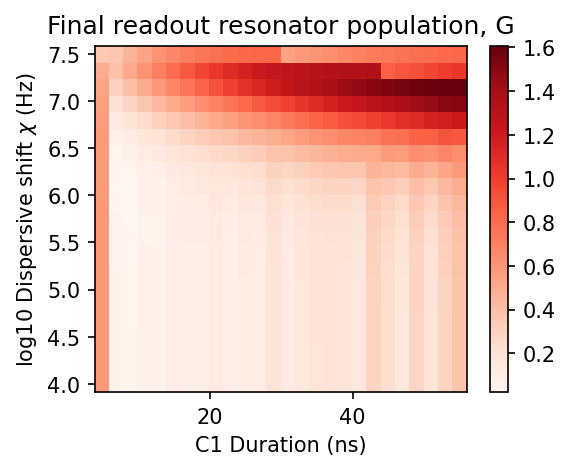

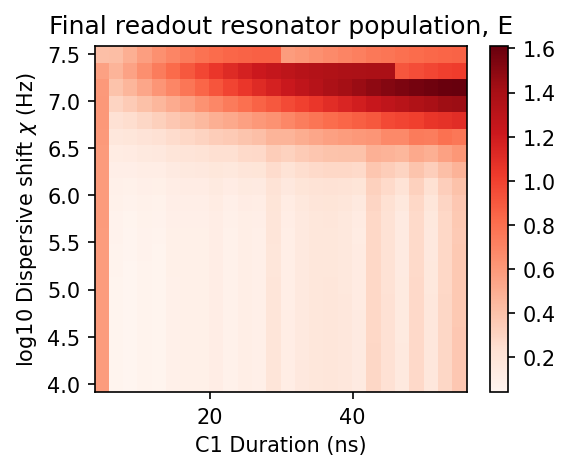

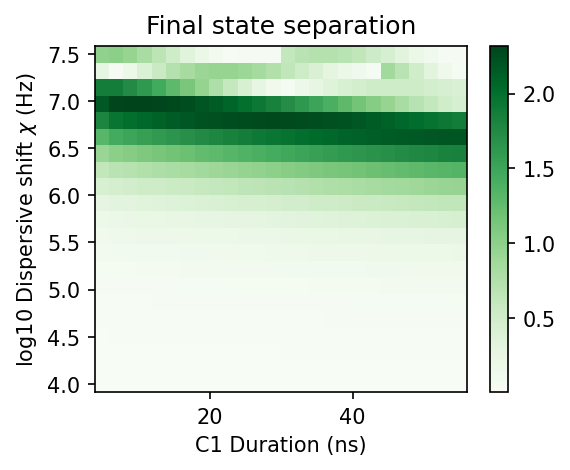

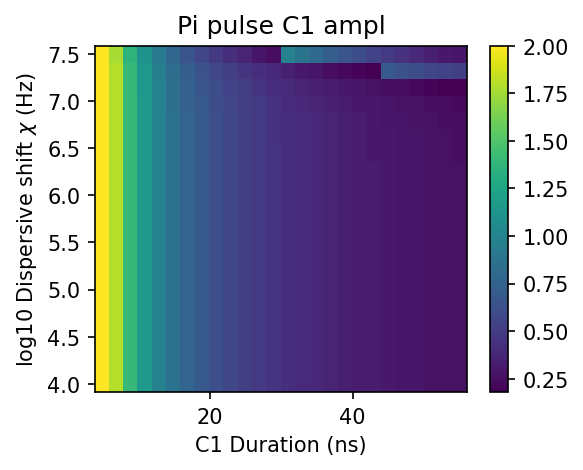

In [11]:
plt.figure(figsize=(4,3),dpi=150)
plt.pcolor((stopC1-startC1)*1e9, logchi, a_residual_nbar[:,:,0],cmap='Reds')
plt.ylabel('log10 Dispersive shift $\chi$ (Hz)')
plt.xlabel('C1 Duration (ns)')
plt.title('Final readout resonator population, G')
plt.colorbar()

plt.figure(figsize=(4,3),dpi=150)
plt.pcolor((stopC1-startC1)*1e9, logchi, a_residual_nbar[:,:,1],cmap='Reds')
plt.ylabel('log10 Dispersive shift $\chi$ (Hz)')
plt.xlabel('C1 Duration (ns)')
plt.title('Final readout resonator population, E')
plt.colorbar()

plt.figure(figsize=(4,3),dpi=150)
plt.pcolor((stopC1-startC1)*1e9, logchi, b_final_separation,cmap='Greens')
plt.ylabel('log10 Dispersive shift $\chi$ (Hz)')
plt.xlabel('C1 Duration (ns)')
plt.title('Final state separation')
plt.colorbar()

plt.figure(figsize=(4,3),dpi=150)
plt.pcolor((stopC1-startC1)*1e9, logchi, best_amplC1[:,:,0])
plt.ylabel('log10 Dispersive shift $\chi$ (Hz)')
plt.xlabel('C1 Duration (ns)')
plt.title('Pi pulse C1 ampl')
plt.colorbar()

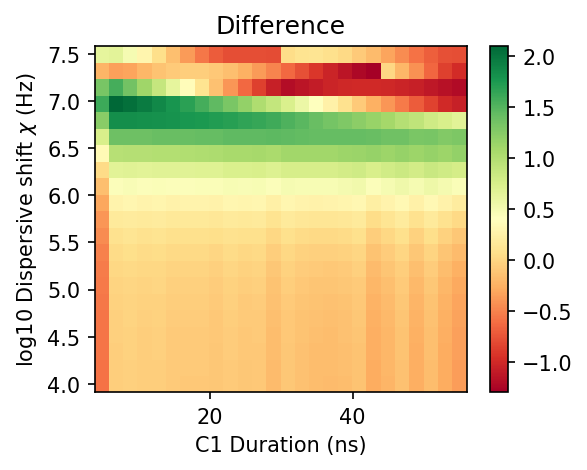

In [10]:
plt.figure(figsize=(4,3),dpi=150)
plt.pcolor((stopC1-startC1)*1e9, logchi,  b_final_separation-a_residual_nbar[:,:,0],cmap='RdYlGn')
plt.title('Difference')
plt.ylabel('log10 Dispersive shift $\chi$ (Hz)')
plt.xlabel('C1 Duration (ns)')
plt.colorbar()

In [12]:
sim.param_dict_nosweep

{'wa': 37699111843.077515,
 'wb': 25132741228.718346,
 'wc': 47123889803.84689,
 'logchi': 5.75,
 'stopC1': 7.599999999999999e-08,
 'logka': 4,
 'kb': 1256637.0614359172,
 'kc': 25132741.228718344,
 'gab': 62831853.071795866,
 'gbc': 62831853.071795866,
 'g3': 314159265.3589793,
 'gr': 62831853.071795866,
 'qbstate': 1.0,
 'amplR': 0.8,
 'amplC1': 1.0,
 'amplG': 0.0,
 'amplC2': 0.0,
 'wR': 37699111843.077515,
 'wC1': -12566370614.359173,
 'wG': 50265482457.43669,
 'wC2': 21991148575.12855,
 'rampR': 1e-09,
 'rampC1': 1e-09,
 'rampG': 1e-09,
 'rampC2': 1e-09,
 'startR': 1.5e-08,
 'stopR': 3.5e-08,
 'startC1': 4.5e-08,
 'startG': 1.1e-07,
 'stopG': 1.7e-07,
 'startC2': 1.9e-07,
 'stopC2': 1.95e-07,
 'phaseR': -0.7853981633974483,
 'phaseC1': 1.0471975511965976,
 'phaseG': 2.764601535159018,
 'phaseC2': 0.0}